In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_curve,
    auc
)



In [29]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df['target'] = iris.target

print("First 5 Rows:\n")
print(df.head())


First 5 Rows:

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [30]:
X = df.drop('target', axis=1)
y = df['target']

In [31]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
error_rate = []

for k in range(1, 21):

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train, y_train)

    pred_k = model.predict(X_test)

    error = np.mean(pred_k != y_test)

    error_rate.append(error)


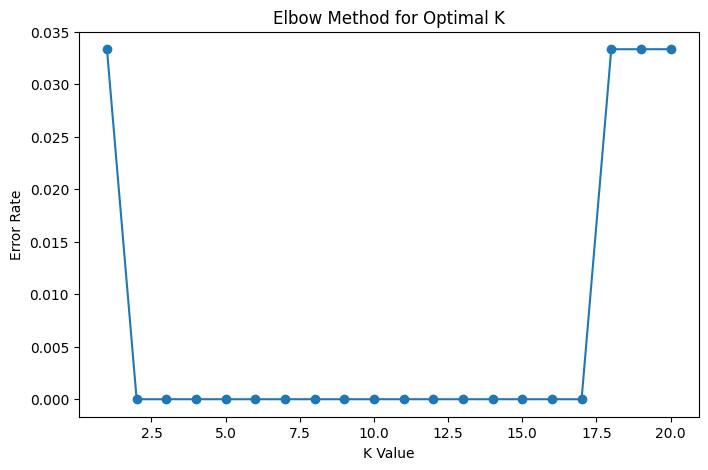

In [34]:
# Plot Elbow Graph
plt.figure(figsize=(8,5))

plt.plot(
    range(1, 21),
    error_rate,
    marker='o'
)

plt.xlabel("K Value")
plt.ylabel("Error Rate")
plt.title("Elbow Method for Optimal K")

plt.show()

In [ ]:
#model training
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)


,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [ ]:
#model prediction
y_pred = knn.predict(X_test)

In [37]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)



Accuracy: 1.0


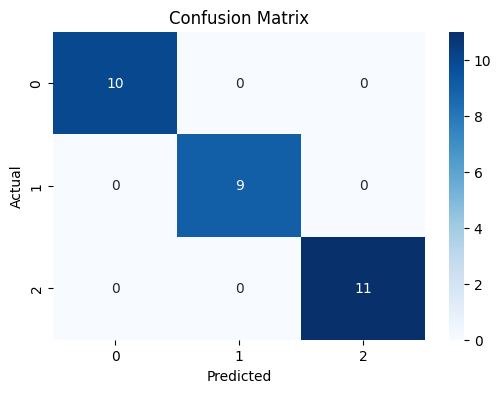

In [ ]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [39]:
# Convert target into binary format
y_bin = label_binarize(y, classes=[0, 1, 2])

# Split again for ROC
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_scaled,
    y_bin,
    test_size=0.2,
    random_state=42
)

# One-vs-Rest KNN
classifier = OneVsRestClassifier(
    KNeighborsClassifier(n_neighbors=3)
)

classifier.fit(X_train_bin, y_train_bin)

# Probability predictions
y_score = classifier.predict_proba(X_test_bin)

# Plot ROC Curves
plt.figure(figsize=(8,5))


<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

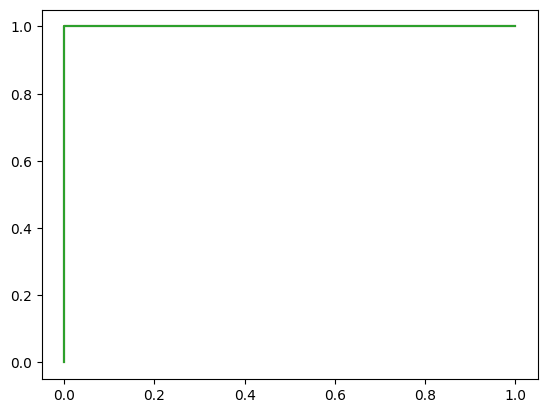

In [40]:
for i in range(3):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'Class {i} AUC = {roc_auc:.2f}'
    )

C:\Users\akkir\AppData\Local\Temp\ipykernel_10312\2089943839.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


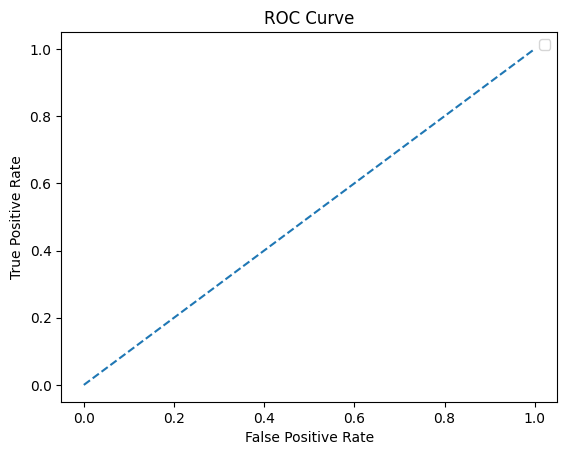

In [41]:
# Random line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()